In [3]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.matlib

In [4]:
from sklearn.metrics import accuracy_score
numpy.random.seed(42) 

In [5]:
#Training data and training label
#Creating dataset 
c1 = [2,3]# Cluster center for class 1 data
c2 = [10,11]# Cluster center for class 2 data
no = 50 # No of samples in a class
class1 = np.matlib.repmat(c1,no,1) + np.random.randn(no,len(c1))
class2 = np.matlib.repmat(c2, no,1)+ np.random.randn(no,len(c2))
D = np.append(class1,class2,axis =0)
Data = np.concatenate((D, np.ones((2*no,1))),axis = 1)
c1_label = np.ones((no,1))
c2_label = -1*np.ones((no,1))
label = np.concatenate((c1_label,c2_label),axis = 0)
Data = Data.T
y = label.T# True label 

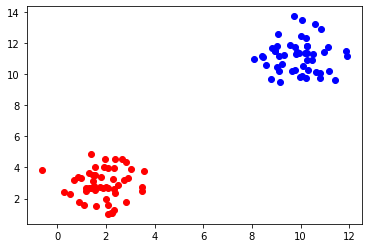

In [6]:
#Plotting data
import matplotlib.pyplot as plt
plt.plot(class1[:,0],class1[:,1],'ro',class2[:,0],class2[:,1],'bo')
plt.show()

In [7]:
#Validation data 
v1 = [5,4]# Cluster center for class1 data of validation data set
v2 = [7,12]# Cluster center for class 2 data of validation data set
v_no = 30# No of samples in a class
v_class1 = np.matlib.repmat(v1,v_no,1) + np.random.randn(v_no,len(v1))
v_class2 = np.matlib.repmat(v2, v_no,1)+ np.random.randn(v_no,len(v2))
v_D = np.append(v_class1,v_class2,axis =0)
v_Data = np.concatenate((v_D, np.ones((2*v_no,1))),axis = 1)
v_c1_label = np.ones((v_no,1))
v_c2_label = -1*np.ones((v_no,1))
v_label = np.concatenate((v_c1_label,v_c2_label),axis = 0)
v_Data = v_Data.T
v_y = v_label.T# Test labe

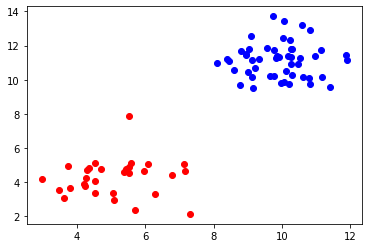

In [8]:
import matplotlib.pyplot as plt
plt.plot(v_class1[:,0],v_class1[:,1],'ro',class2[:,0],class2[:,1],'bo')
plt.show()

In [18]:
#The activation function used is sigmoid
def sigmoid(x):
     a = 1/(1+np.exp(-x))
     return a 
def prediction(w, Data):
     pred = []
     z = np.dot(w,Data)
     a = sigmoid(z)
     for i in range(0,len(a[0])):
         if (a[0][i] > 0.5): 
             pred.append(1)
         elif (a[0][i] <= 0.5):
             pred.append(-1)
     return pred

In [48]:
#Training part- In this step the loss is calculated and minimized with respect to weights.
learning_rate = 0.01
w = np.random.randn(1,3)
for i in range(1,1500):
     z = np.dot(w,Data)
     y_pred = prediction(w, Data)
     val = -np.multiply(y,z)
     J = np.sum(np.log(1+np.exp(val)))
     num = -np.multiply(y,np.exp(val))
     den = 1+np.exp(val)
     f = num/den
     gradJ = np.dot(Data,f.T)
     w = w - learning_rate*gradJ.T
     print("Epoch",i,"Loss",J,"Training Accuracy",accuracy_score(y[0],y_pred)*100) 


Epoch 1 Loss 354.60811931309917 Training Accuracy 49.0
Epoch 2 Loss 1167.420638159736 Training Accuracy 50.0
Epoch 3 Loss 841.2012926952827 Training Accuracy 50.0
Epoch 4 Loss 515.0107724980126 Training Accuracy 50.0
Epoch 5 Loss 192.19367372637444 Training Accuracy 51.0
Epoch 6 Loss 237.31755973020037 Training Accuracy 49.0
Epoch 7 Loss 1112.6009993145667 Training Accuracy 50.0
Epoch 8 Loss 786.3847118340482 Training Accuracy 50.0
Epoch 9 Loss 460.61396757812247 Training Accuracy 50.0
Epoch 10 Loss 150.47355460877668 Training Accuracy 55.00000000000001
Epoch 11 Loss 47.80062097967974 Training Accuracy 75.0
Epoch 12 Loss 330.5429650575488 Training Accuracy 51.0
Epoch 13 Loss 62.62392099286252 Training Accuracy 73.0
Epoch 14 Loss 43.32100829916886 Training Accuracy 76.0
Epoch 15 Loss 295.5066365173245 Training Accuracy 52.0
Epoch 16 Loss 47.67466947533872 Training Accuracy 78.0
Epoch 17 Loss 19.523676983716612 Training Accuracy 91.0
Epoch 18 Loss 67.65774275912366 Training Accuracy 72.0

In [ ]:
#Prediction for test data
Test_predict = prediction(w, v_Data)
print("Test Accuracy",accuracy_score(v_y[0], Test_predict)*100)

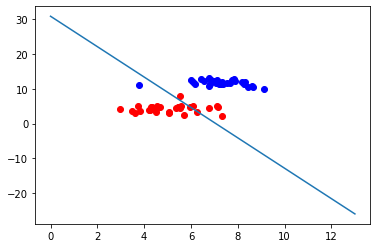

In [49]:
domain = np.linspace(0,13,100)
h_x = -(w[0,0]/w[0,1])*domain - (w[0,2]/w[0,1]) 
plt.plot(v_class1[:,0],v_class1[:,1],'ro',v_class2[:,0],v_class2[:,1],'bo')
plt.plot(domain,h_x)
plt.show()